# **Memory Leak Analysis**



In [4]:
# @title
import pandas as pd
import numpy as np
import matplotlib as plt

df = pd.read_csv('memory_leak_experiments_results.csv')
df.loc[df['leak_injected'] == True, 'leak_injected'] = 1
df.loc[df['leak_injected'] == False, 'leak_injected'] = 0
print(len(df))

df.tail()

50


/tmp/ipykernel_15634/3434310598.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df['leak_injected'] == True, 'leak_injected'] = 1


,experiment_id,leak_injected,threshold,duration,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive,precision_class_0,recall_class_0,f1_class_0,precision_class_1,recall_class_1,f1_class_1
45,memory-chaos-74173_1777767549,1,50000,0.382161,1.000000,1.0,1.0,1.000000,13,0,0,1,1.000000,1.000000,1.00,1.0,1.0,1.000000
46,memory-chaos-55926_1777767755,1,50000,0.375889,1.000000,1.0,1.0,1.000000,13,0,0,1,1.000000,1.000000,1.00,1.0,1.0,1.000000
47,memory-chaos-55775_1777767961,1,50000,0.264813,1.000000,1.0,1.0,1.000000,12,0,0,2,1.000000,1.000000,1.00,1.0,1.0,1.000000
48,memory-chaos-39518_1777768167,1,50000,0.270248,0.928571,1.0,0.5,0.666667,12,0,1,1,0.923077,1.000000,0.96,1.0,0.5,0.666667
49,memory-chaos-4880_1777768372,1,50000,0.349871,0.785714,0.0,0.0,0.000000,11,1,2,0,0.846154,0.916667,0.88,0.0,0.0,0.000000


**Evaluation Metrics (Accuracy, Recall, Precision and F1-Score)**

In [5]:
injected_df = df.tail(50)
injected_df = injected_df[injected_df['leak_injected'] == 1]

print(f"Experimentos: {len(injected_df)}\n")

print(f"Acurácia: {np.mean(injected_df['accuracy']):.2f}")
print(f"Precisão: {np.mean(injected_df['precision_class_1']):.2f}")
print(f"Recall: {np.mean(injected_df['recall_class_1']):.2f}")
print(f"F1-Score: {np.mean(injected_df['f1_class_1']):.2f}")


Experimentos: 44

Acurácia: 0.96
Precisão: 0.81
Recall: 0.86
F1-Score: 0.82


**Confusion Matrix Quadrants Quantity**

In [7]:
# @title
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
filter_df = df.tail(50)
categories = filter_df.columns[8:12].to_list()
values = filter_df[categories].sum()
print(categories)
print(values)

['true_negative', 'false_positive', 'false_negative', 'true_positive']
true_negative     612
false_positive     18
false_negative     10
true_positive      60
dtype: int64


**Execution Time Analysis**

In [8]:
time_df = df.tail(50)
time_col = time_df["duration"]

media = time_df["duration"].mean()
desvio_padrao = time_df["duration"].std()
p90 = time_df["duration"].quantile(0.90)
p95 = time_df["duration"].quantile(0.95)
max = time_df["duration"].max()
min = time_df["duration"].min()

print(f"média: {media}")
print(f"std: {desvio_padrao}")
print(f"p90: {p90}")
print(f"p95: {p95}")
print(f"max: {max}")
print(f"min: {min}")

média: 0.3304674816131592
std: 0.12342509024708537
p90: 0.4865360260009765
p95: 0.5950048565864561
max: 0.7114226818084717
min: 0.2090461254119873


**Confusion Matrix Display**

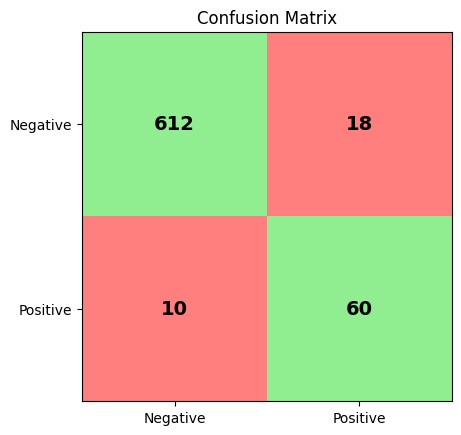

In [9]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# matriz de confusão
cm = np.array([
    [612, 18],
    [10, 60]
])

# matriz para cores (0=verde, 1=vermelho)
color_matrix = np.array([
    [0, 1],
    [1, 0]
])

cmap = ListedColormap(["#90EE90", "#FF7F7F"])  # verde claro, vermelho claro

fig, ax = plt.subplots()

ax.imshow(color_matrix, cmap=cmap)

# adicionar números
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Negative", "Positive"])
ax.set_yticklabels(["Negative", "Positive"])

plt.title("Confusion Matrix")
plt.show()

# **CPU Hog Analysis**



In [10]:
# @title
import pandas as pd
import numpy as np
import matplotlib as plt

df = pd.read_csv('cpu_experiments_results.csv')

df.loc[df['leak_injected'] == True, 'leak_injected'] = 1
df.loc[df['leak_injected'] == False, 'leak_injected'] = 0
print(len(df))

df.tail()

50


/tmp/ipykernel_15634/1267645102.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df['leak_injected'] == True, 'leak_injected'] = 1


,experiment_id,leak_injected,threshold,duration,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive,precision_class_0,recall_class_0,f1_class_0,precision_class_1,recall_class_1,f1_class_1
45,cpu-chaos-86510_1777747590,1,50000,0.578490,1.0,1.0,1.0,1.0,13,0,0,1,1.0,1.0,1.0,1.0,1.0,1.0
46,None_1777747796,0,50000,0.556067,1.0,0.0,0.0,0.0,14,0,0,0,1.0,1.0,1.0,0.0,0.0,0.0
47,None_1777748002,0,50000,0.942900,1.0,0.0,0.0,0.0,14,0,0,0,1.0,1.0,1.0,0.0,0.0,0.0
48,cpu-chaos-85653_1777748208,1,50000,0.792379,1.0,1.0,1.0,1.0,12,0,0,2,1.0,1.0,1.0,1.0,1.0,1.0
49,cpu-chaos-8914_1777748628,1,50000,0.662158,1.0,1.0,1.0,1.0,13,0,0,1,1.0,1.0,1.0,1.0,1.0,1.0


**Evaluation Metrics (Accuracy, Recall, Precision and F1-Score)**

In [11]:
injected_df = df.tail(50)
injected_df = injected_df[injected_df['leak_injected'] == 1]

print(f"Experimentos: {len(injected_df)}\n")

print(f"Acurácia: {np.mean(injected_df['accuracy']):.2f}")
print(f"Precisão: {np.mean(injected_df['precision_class_1']):.2f}")
print(f"Recall: {np.mean(injected_df['recall_class_1']):.2f}")
print(f"F1-Score: {np.mean(injected_df['f1_class_1']):.2f}")

Experimentos: 42

Acurácia: 0.99
Precisão: 0.90
Recall: 0.88
F1-Score: 0.88


**Confusion Matrix Quadrants Quantity**



In [12]:
# @title
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
filter_df = df.tail(50)
categories = filter_df.columns[8:12].to_list()
values = filter_df[categories].sum()
print(categories)
print(values)

['true_negative', 'false_positive', 'false_negative', 'true_positive']
true_negative     635
false_positive      1
false_negative      7
true_positive      57
dtype: int64


**Execution Time Analysis**

In [13]:
time_df = df.tail(50)
time_col = time_df["duration"]

media = time_df["duration"].mean()
desvio_padrao = time_df["duration"].std()
p90 = time_df["duration"].quantile(0.90)
p95 = time_df["duration"].quantile(0.95)
max = time_df["duration"].max()
min = time_df["duration"].min()

print(f"média: {media}")
print(f"std: {desvio_padrao}")
print(f"p90: {p90}")
print(f"p95: {p95}")
print(f"max: {max}")
print(f"min: {min}")

média: 0.5198458051681518
std: 0.24162885894084557
p90: 0.8191476583480836
p95: 0.9084624648094176
max: 1.125969648361206
min: 0.2269594669342041


**Confusion Matrix Display**

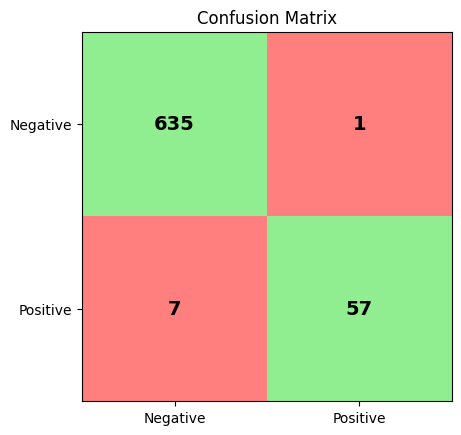

In [14]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# matriz de confusão
cm = np.array([
    [635, 1],
    [7, 57]
])

# matriz para cores (0=verde, 1=vermelho)
color_matrix = np.array([
    [0, 1],
    [1, 0]
])

cmap = ListedColormap(["#90EE90", "#FF7F7F"])  # verde claro, vermelho claro

fig, ax = plt.subplots()

ax.imshow(color_matrix, cmap=cmap)

# adicionar números
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Negative", "Positive"])
ax.set_yticklabels(["Negative", "Positive"])

plt.title("Confusion Matrix")
plt.show()